In [1]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
# import langchain tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain.tools import tool

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


/tmp/ipykernel_185691/2842819713.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
#==========setup model ===========
llm=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.5,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


class SocialMediaState(TypedDict):
    topic: str
    instagram_post: str
    linkedin_post: str
    facebook_post: str


In [8]:
def create_instagram_post(state: SocialMediaState):
    prompt = f"""
    You are a social media expert.
    Write an Instagram post about: {state['topic']}.
    Keep it short, catchy, and engaging.
    Add a strong hook, emojis, and 3 relevant hashtags.
    """

    response = llm.invoke(prompt)
    return {"instagram_post": response.content}


def create_linkedin_post(state: SocialMediaState):
    prompt = f"""
    You are a professional content writer.
    Write a LinkedIn post about: {state['topic']}.
    Keep it professional, clear, and insightful.
    End with a thoughtful question.
    """

    response = llm.invoke(prompt)
    return {"linkedin_post": response.content}


def create_facebook_post(state: SocialMediaState):
    prompt = f"""
    You are a friendly community manager.
    Write a Facebook post about: {state['topic']}.
    Make it warm, conversational, and easy to read.
    Add a call to action that invites comments.
    """

    response = llm.invoke(prompt)
    return {"facebook_post": response.content}

In [9]:
#==========setup graph ===========
parallel_graph = StateGraph(SocialMediaState)

parallel_graph.add_node("create_instagram_post", create_instagram_post)
parallel_graph.add_node("create_linkedin_post", create_linkedin_post)
parallel_graph.add_node("create_facebook_post", create_facebook_post)

parallel_graph.add_edge(START, "create_instagram_post")
parallel_graph.add_edge(START, "create_linkedin_post")
parallel_graph.add_edge(START, "create_facebook_post")

parallel_graph.add_edge("create_instagram_post", END)
parallel_graph.add_edge("create_linkedin_post", END)
parallel_graph.add_edge("create_facebook_post", END)

parallel_graph = parallel_graph.compile()

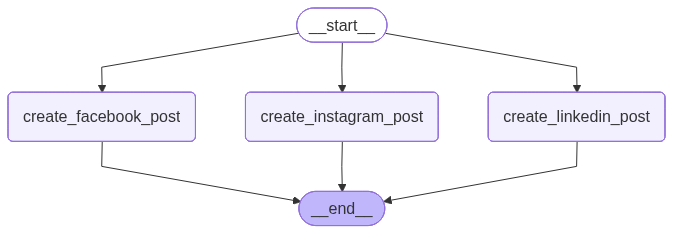

In [10]:
display(Image(parallel_graph.get_graph().draw_mermaid_png()))

In [11]:
sample_topic = "How AI is changing the future of education"
initial_state = SocialMediaState(
    topic=sample_topic,
    instagram_post="",
    linkedin_post="",
    facebook_post=""
)

output = parallel_graph.invoke(initial_state)
output

{'topic': 'How AI is changing the future of education',
 'instagram_post': [{'type': 'text',
   'text': "Is the classroom of the future already here? 🤖📚\n\nForget one-size-fits-all learning. AI is turning education into a personalized experience, acting as a 24/7 tutor that adapts to *your* unique pace and style. From instant feedback to breaking down complex topics in seconds, the way we learn is evolving faster than ever. 🚀\n\nThe question isn't if AI will change education—it’s how you’ll use it to unlock your potential. 💡\n\nAre you ready for the AI-powered classroom? Let’s chat in the comments! 👇\n\n#FutureOfEducation #EdTech #AIinEducation",
   'extras': {'signature': 'EjQKMgEMOdbHqcROhSH2tMJHTgXAizWcnuZqzQKFhHsNphLk3sgrWMztLhT+9jTGaNkuQ8vG'}}],
 'linkedin_post': [{'type': 'text',
   'text': 'The traditional "one-size-fits-all" model of education is rapidly becoming a relic of the past. \n\nWe are currently witnessing a seismic shift in how knowledge is delivered, consumed, and ma

In [12]:
print("Instagram Post:\n")
print(output["instagram_post"])

print("\n" + "=" * 80 + "\n")
print("LinkedIn Post:\n")
print(output["linkedin_post"])

print("\n" + "=" * 80 + "\n")
print("Facebook Post:\n")
print(output["facebook_post"])


Instagram Post:

[{'type': 'text', 'text': "Is the classroom of the future already here? 🤖📚\n\nForget one-size-fits-all learning. AI is turning education into a personalized experience, acting as a 24/7 tutor that adapts to *your* unique pace and style. From instant feedback to breaking down complex topics in seconds, the way we learn is evolving faster than ever. 🚀\n\nThe question isn't if AI will change education—it’s how you’ll use it to unlock your potential. 💡\n\nAre you ready for the AI-powered classroom? Let’s chat in the comments! 👇\n\n#FutureOfEducation #EdTech #AIinEducation", 'extras': {'signature': 'EjQKMgEMOdbHqcROhSH2tMJHTgXAizWcnuZqzQKFhHsNphLk3sgrWMztLhT+9jTGaNkuQ8vG'}}]


LinkedIn Post:

[{'type': 'text', 'text': 'The traditional "one-size-fits-all" model of education is rapidly becoming a relic of the past. \n\nWe are currently witnessing a seismic shift in how knowledge is delivered, consumed, and mastered. Artificial Intelligence isn\'t just an "add-on" to the class